In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
base_path = "/content/drive/MyDrive/2026-Summer/IDXExchange-Intern"
output_path = f"{base_path}/week5_outputs"

os.makedirs(output_path, exist_ok=True)

In [4]:
train_df = pd.read_csv(f"{base_path}/split-data/cleaned_train.csv")
validation_df = pd.read_csv(f"{base_path}/split-data/cleaned_validation.csv")
test_df = pd.read_csv(f"{base_path}/split-data/cleaned_test.csv")

for df in [train_df, validation_df, test_df]:
    df["CloseDate"] = pd.to_datetime(df["CloseDate"])

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

print("\nTrain period:", train_df["CloseDate"].min(), "to", train_df["CloseDate"].max())
print("Validation period:", validation_df["CloseDate"].min(), "to", validation_df["CloseDate"].max())
print("Test period:", test_df["CloseDate"].min(), "to", test_df["CloseDate"].max())

Train: (129555, 40)
Validation: (31758, 40)
Test: (12024, 40)

Train period: 2025-02-01 00:00:00 to 2026-01-31 00:00:00
Validation period: 2026-02-01 00:00:00 to 2026-04-30 00:00:00
Test period: 2026-05-01 00:00:00 to 2026-05-31 00:00:00


In [5]:
# Separate features and target values

target = "ClosePrice"
exclude_cols = [target, "CloseDate", "split"]

feature_cols = [
    col for col in train_df.columns
    if col not in exclude_cols
]

X_validation = validation_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_validation = validation_df[target].copy()
y_test = test_df[target].copy()

In [6]:
# Define functions for evaluation and residual analysis

def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


def fit_and_evaluate(
    model,
    X_fit,
    y_fit,
    X_eval,
    y_eval,
    model_name,
    data_version,
    parameters=""
):
    fitted_model = clone(model)
    fitted_model.fit(X_fit, y_fit)
    predictions = fitted_model.predict(X_eval)

    result = {
        "Model": model_name,
        "Data Version": data_version,
        "Parameters": parameters,
        **regression_metrics(y_eval, predictions),
    }

    return fitted_model, predictions, result


def residual_diagnostics(y_true, y_pred, title):
    residuals = np.asarray(y_true) - np.asarray(y_pred)

    min_value = min(np.min(y_true), np.min(y_pred))
    max_value = max(np.max(y_true), np.max(y_pred))

    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
    plt.title(f"{title}: Actual vs Predicted")
    plt.xlabel("Actual ClosePrice")
    plt.ylabel("Predicted ClosePrice")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, residuals, alpha=0.3)
    plt.axhline(0, linestyle="--")
    plt.title(f"{title}: Residuals vs Predicted")
    plt.xlabel("Predicted ClosePrice")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=40)
    plt.title(f"{title}: Residual Distribution")
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    return pd.Series(residuals, index=y_true.index, name="Residual")

In [7]:
# Compare different training windows using Linear Regression only

window_results = []

for months in [3, 6, 9, 12]:
    train_end = train_df["CloseDate"].max()
    train_start = (
        train_end.to_period("M").to_timestamp()
        - pd.DateOffset(months=months - 1)
    )

    current_train = train_df[train_df["CloseDate"] >= train_start].copy()

    X_train_window = current_train[feature_cols]
    y_train_window = current_train[target]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    _, _, result = fit_and_evaluate(
        model,
        X_train_window,
        y_train_window,
        X_validation,
        y_validation,
        "Linear Regression",
        f"{months} Months"
    )

    result["Training Months"] = months
    window_results.append(result)

training_window_results = (
    pd.DataFrame(window_results)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

training_window_results

,Model,Data Version,Parameters,R2,RMSE,MAE,Training Months
0,Linear Regression,3 Months,,0.015279,9.655655e+06,512612.509236,3
1,Linear Regression,12 Months,,0.015278,9.655661e+06,541209.738950,12
2,Linear Regression,6 Months,,0.015101,9.656531e+06,525386.051450,6
3,Linear Regression,9 Months,,0.010263,9.680215e+06,572285.006761,9


In [8]:
# Select the best training window

best_months = int(training_window_results.iloc[0]["Training Months"])

train_end = train_df["CloseDate"].max()
train_start = (
    train_end.to_period("M").to_timestamp()
    - pd.DateOffset(months=best_months - 1)
)

train_df = train_df[train_df["CloseDate"] >= train_start].copy()

X_train = train_df[feature_cols].copy()
y_train = train_df[target].copy()

print(f"Selected training window: {best_months} months")
print(f"Training period: {train_df['CloseDate'].min().date()} ~ {train_df['CloseDate'].max().date()}")
print(f"Training rows: {len(train_df)}")

Selected training window: 3 months
Training period: 2025-11-01 ~ 2026-01-31
Training rows: 27684


In [9]:
# Train and evaluate the baseline Linear Regression model

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

baseline_fitted, baseline_pred, baseline_result = fit_and_evaluate(
    baseline_model,
    X_train,
    y_train,
    X_validation,
    y_validation,
    "Linear Regression",
    "Before Outlier Removal",
    "StandardScaler + LinearRegression"
)

pd.DataFrame([baseline_result])

,Model,Data Version,Parameters,R2,RMSE,MAE
0,Linear Regression,Before Outlier Removal,StandardScaler + LinearRegression,0.015279,9.655655e+06,512612.509236


In [10]:
# Decision Tree model using validation

decision_tree_results = []

for max_depth in [5, 10, 20, None]:
    for min_samples_leaf in [1, 5, 10, 20]:
        model = DecisionTreeRegressor(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

        _, _, result = fit_and_evaluate(
            model,
            X_train,
            y_train,
            X_validation,
            y_validation,
            "Decision Tree",
            "Before Outlier Removal",
            f"max_depth={max_depth}, min_samples_leaf={min_samples_leaf}"
        )

        result["max_depth"] = max_depth
        result["min_samples_leaf"] = min_samples_leaf
        decision_tree_results.append(result)

decision_tree_tuning_df = (
    pd.DataFrame(decision_tree_results)
    .sort_values(["R2", "RMSE", "MAE"], ascending=[False, True, True])
    .reset_index(drop=True)
)

decision_tree_tuning_df.head()

,Model,Data Version,Parameters,R2,RMSE,MAE,max_depth,min_samples_leaf
0,Decision Tree,Before Outlier Removal,"max_depth=5, min_samples_leaf=1",0.013748,9.663158e+06,544814.553638,5.0,1
1,Decision Tree,Before Outlier Removal,"max_depth=None, min_samples_leaf=1",0.012381,9.669852e+06,438863.172309,NaN,1
2,Decision Tree,Before Outlier Removal,"max_depth=5, min_samples_leaf=20",0.007419,9.694116e+06,556899.592998,5.0,20
3,Decision Tree,Before Outlier Removal,"max_depth=5, min_samples_leaf=10",0.004265,9.709502e+06,563012.741639,5.0,10
4,Decision Tree,Before Outlier Removal,"max_depth=10, min_samples_leaf=20",0.001103,9.724908e+06,468937.777607,10.0,20


In [11]:
# Create the best Decision Tree model

best_dt_row = decision_tree_tuning_df.iloc[0]

max_depth = best_dt_row["max_depth"]
if pd.notna(max_depth):
    max_depth = int(max_depth)
else:
    max_depth = None

best_dt_model = DecisionTreeRegressor(
    max_depth=max_depth,
    min_samples_leaf=int(best_dt_row["min_samples_leaf"]),
    random_state=42
)

dt_fitted, dt_pred, dt_result = fit_and_evaluate(
    best_dt_model,
    X_train,
    y_train,
    X_validation,
    y_validation,
    "Decision Tree",
    "Before Outlier Removal",
    best_dt_row["Parameters"]
)

pd.DataFrame([dt_result])

,Model,Data Version,Parameters,R2,RMSE,MAE
0,Decision Tree,Before Outlier Removal,"max_depth=5, min_samples_leaf=1",0.013748,9.663158e+06,544814.553638


In [12]:
# Random Forest model using validation

random_forest_results = []

for n_estimators in [100]:
    for max_depth in [10, 20, None]:
        for min_samples_leaf in [1, 5]:
            model = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=42,
                n_jobs=-1
            )

            _, _, result = fit_and_evaluate(
                model,
                X_train,
                y_train,
                X_validation,
                y_validation,
                "Random Forest",
                "Before Outlier Removal",
                (
                    f"n_estimators={n_estimators}, "
                    f"max_depth={max_depth}, "
                    f"min_samples_leaf={min_samples_leaf}"
                )
            )

            result["n_estimators"] = n_estimators
            result["max_depth"] = max_depth
            result["min_samples_leaf"] = min_samples_leaf
            random_forest_results.append(result)

random_forest_tuning_df = (
    pd.DataFrame(random_forest_results)
    .sort_values(["R2", "RMSE", "MAE"], ascending=[False, True, True])
    .reset_index(drop=True)
)

random_forest_tuning_df.head()

,Model,Data Version,Parameters,R2,RMSE,MAE,n_estimators,max_depth,min_samples_leaf
0,Random Forest,Before Outlier Removal,"n_estimators=100, max_depth=10, min_samples_le...",0.002356,9.718808e+06,442672.147176,100,10.0,5
1,Random Forest,Before Outlier Removal,"n_estimators=100, max_depth=20, min_samples_le...",0.002340,9.718886e+06,420703.018783,100,20.0,5
2,Random Forest,Before Outlier Removal,"n_estimators=100, max_depth=None, min_samples_...",0.002288,9.719136e+06,420699.276473,100,NaN,5
3,Random Forest,Before Outlier Removal,"n_estimators=100, max_depth=20, min_samples_le...",-0.018445,9.819606e+06,409638.886215,100,20.0,1
4,Random Forest,Before Outlier Removal,"n_estimators=100, max_depth=None, min_samples_...",-0.019807,9.826166e+06,414843.165058,100,NaN,1


In [13]:
# Create the best Random Forest model

best_rf_row = random_forest_tuning_df.iloc[0]

max_depth = (
    None
    if pd.isna(best_rf_row["max_depth"])
    else int(best_rf_row["max_depth"])
)

best_rf_model = RandomForestRegressor(
    n_estimators=int(best_rf_row["n_estimators"]),
    max_depth=max_depth,
    min_samples_leaf=int(best_rf_row["min_samples_leaf"]),
    random_state=42,
    n_jobs=-1
)

rf_fitted, rf_pred, rf_result = fit_and_evaluate(
    best_rf_model,
    X_train,
    y_train,
    X_validation,
    y_validation,
    "Random Forest",
    "Before Outlier Removal",
    best_rf_row["Parameters"]
)

pd.DataFrame([rf_result])

,Model,Data Version,Parameters,R2,RMSE,MAE
0,Random Forest,Before Outlier Removal,"n_estimators=100, max_depth=10, min_samples_le...",0.002356,9.718808e+06,442672.147176


In [14]:
# Compare models before outlier removal

before_results = (
    pd.DataFrame([baseline_result, dt_result, rf_result])
    .sort_values(["R2", "RMSE", "MAE"], ascending=[False, True, True])
    .reset_index(drop=True)
)

before_results

,Model,Data Version,Parameters,R2,RMSE,MAE
0,Linear Regression,Before Outlier Removal,StandardScaler + LinearRegression,0.015279,9.655655e+06,512612.509236
1,Decision Tree,Before Outlier Removal,"max_depth=5, min_samples_leaf=1",0.013748,9.663158e+06,544814.553638
2,Random Forest,Before Outlier Removal,"n_estimators=100, max_depth=10, min_samples_le...",0.002356,9.718808e+06,442672.147176


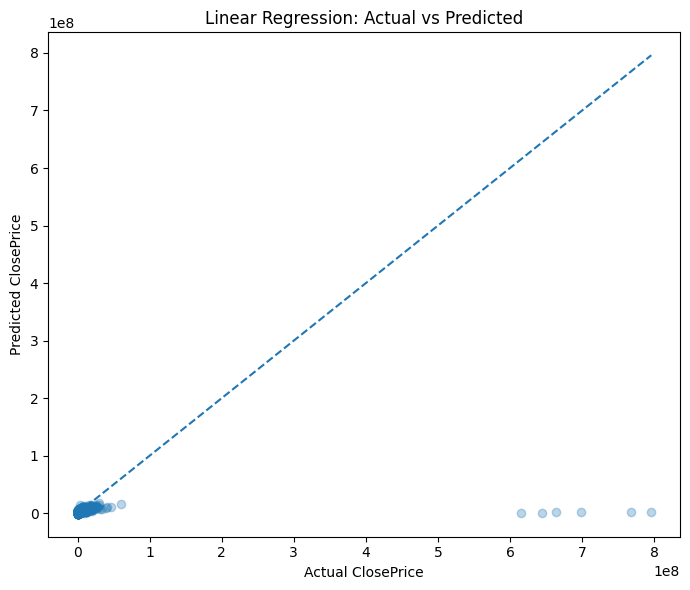

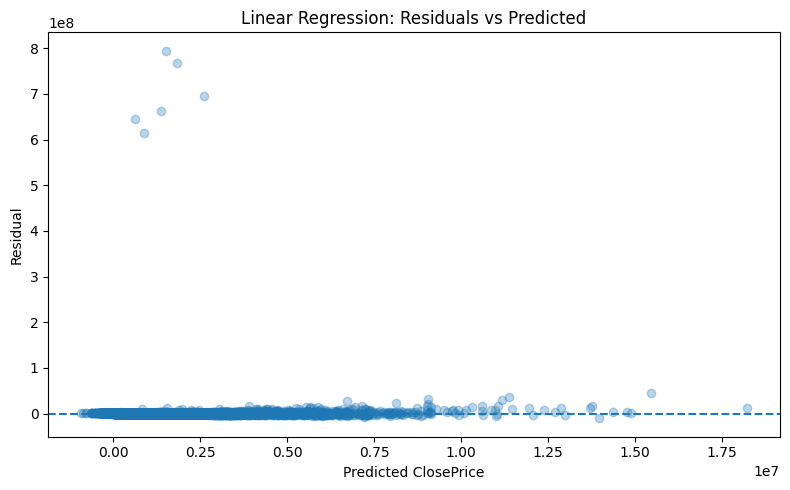

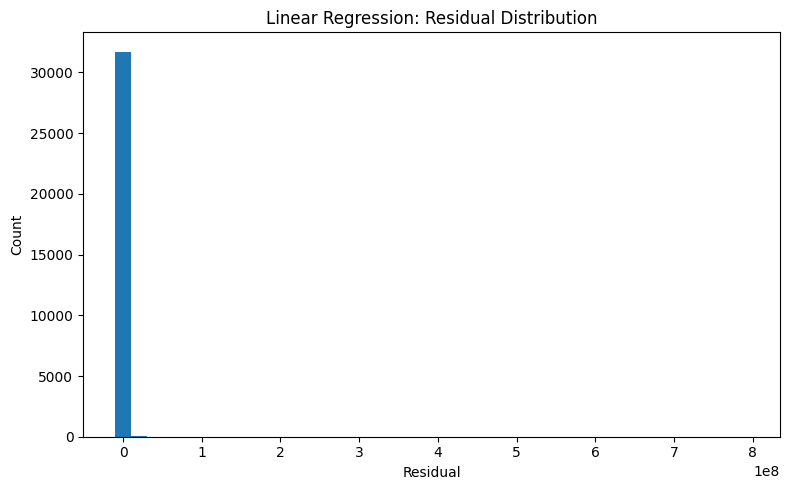

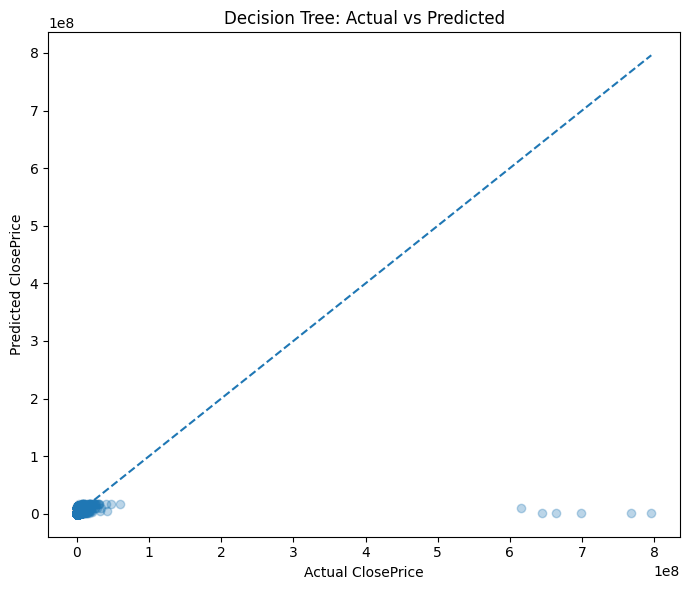

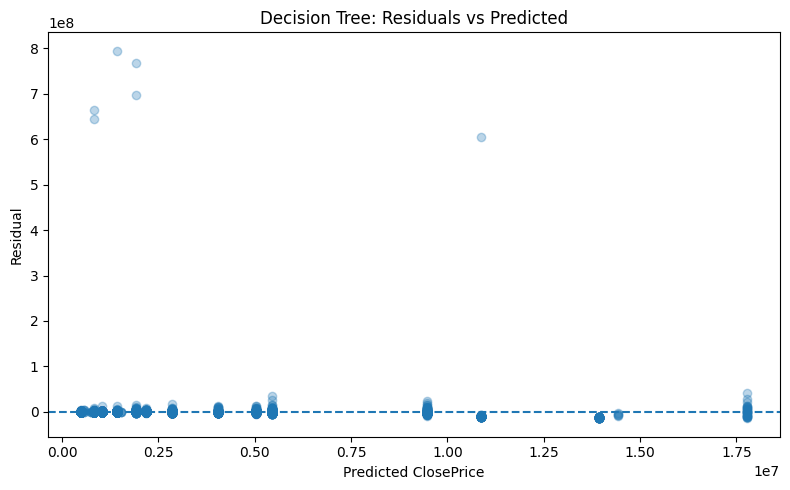

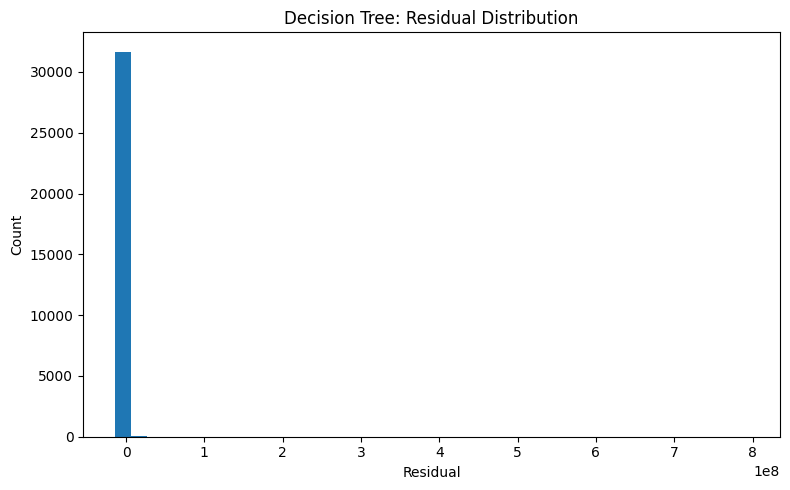

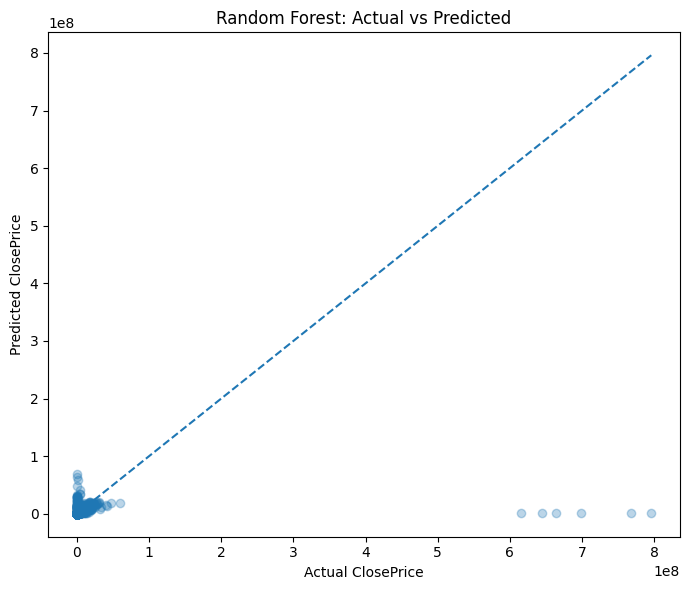

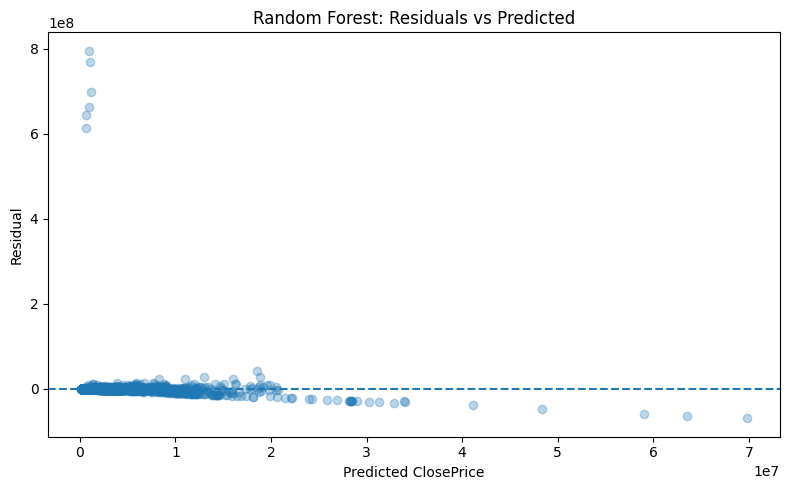

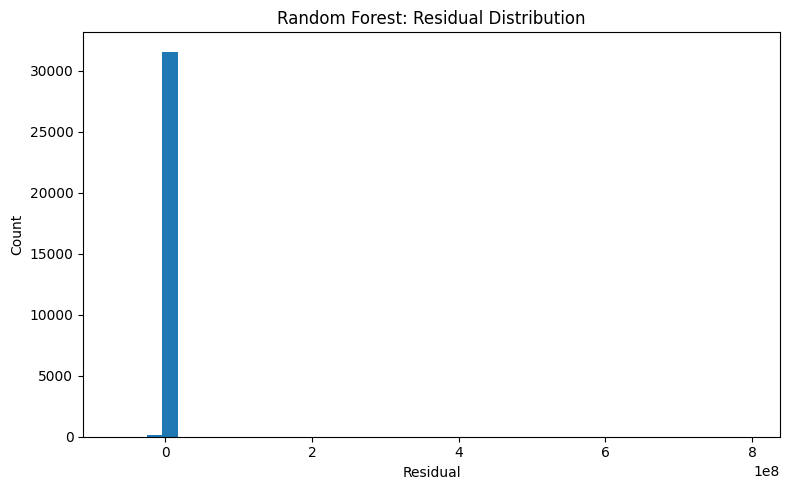

In [15]:
# Plot validation residuals before outlier removal

baseline_residuals = residual_diagnostics(
    y_validation, baseline_pred, "Linear Regression"
)

dt_residuals = residual_diagnostics(
    y_validation, dt_pred, "Decision Tree"
)

rf_residuals = residual_diagnostics(
    y_validation, rf_pred, "Random Forest"
)

In [16]:
# ClosePrice: Identify and remove outliers from the training set

q1 = y_train.quantile(0.25)
q3 = y_train.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

inlier_mask = y_train.between(lower_bound, upper_bound)

X_train_inlier = X_train.loc[inlier_mask].copy()
y_train_inlier = y_train.loc[inlier_mask].copy()

outlier_summary = pd.DataFrame({
    "Original Rows": [len(y_train)],
    "Removed Rows": [(~inlier_mask).sum()],
    "Remaining Rows": [inlier_mask.sum()],
    "Lower Bound": [lower_bound],
    "Upper Bound": [upper_bound],
})

outlier_summary

,Original Rows,Removed Rows,Remaining Rows,Lower Bound,Upper Bound
0,27684,2181,25503,-501845.625,2461107.375


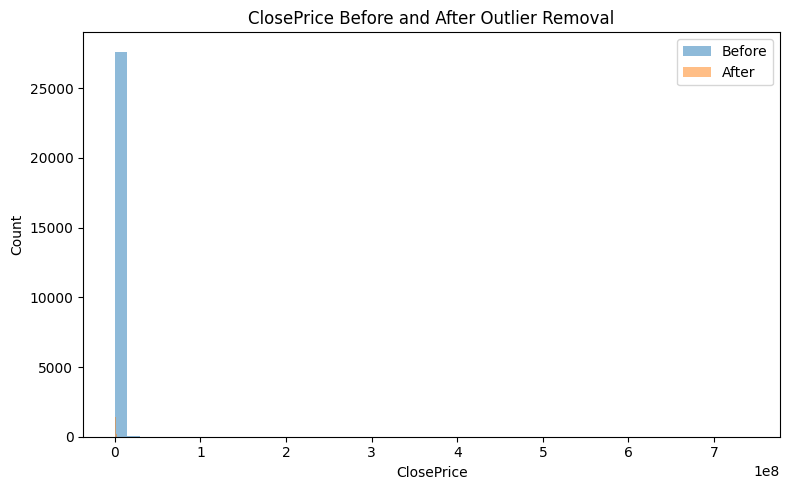

In [17]:
# Compare the target distribution before and after outlier removal

plt.figure(figsize=(8, 5))
plt.hist(y_train, bins=50, alpha=0.5, label="Before")
plt.hist(y_train_inlier, bins=50, alpha=0.5, label="After")
plt.title("ClosePrice Before and After Outlier Removal")
plt.xlabel("ClosePrice")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Retrain and evaluate all models after outlier removal

baseline_after_fitted, baseline_after_pred, baseline_after_result = fit_and_evaluate(
    baseline_model,
    X_train_inlier,
    y_train_inlier,
    X_validation,
    y_validation,
    "Linear Regression",
    "After Outlier Removal",
    "StandardScaler + LinearRegression"
)

dt_after_fitted, dt_after_pred, dt_after_result = fit_and_evaluate(
    best_dt_model,
    X_train_inlier,
    y_train_inlier,
    X_validation,
    y_validation,
    "Decision Tree",
    "After Outlier Removal",
    best_dt_row["Parameters"]
)

rf_after_fitted, rf_after_pred, rf_after_result = fit_and_evaluate(
    best_rf_model,
    X_train_inlier,
    y_train_inlier,
    X_validation,
    y_validation,
    "Random Forest",
    "After Outlier Removal",
    best_rf_row["Parameters"]
)

after_results = (
    pd.DataFrame([
        baseline_after_result,
        dt_after_result,
        rf_after_result
    ])
    .sort_values(["R2", "RMSE", "MAE"], ascending=[False, True, True])
    .reset_index(drop=True)
)

after_results

,Model,Data Version,Parameters,R2,RMSE,MAE
0,Linear Regression,After Outlier Removal,StandardScaler + LinearRegression,0.009456,9.684161e+06,510458.801619
1,Random Forest,After Outlier Removal,"n_estimators=100, max_depth=10, min_samples_le...",0.005056,9.705649e+06,471223.490296
2,Decision Tree,After Outlier Removal,"max_depth=5, min_samples_leaf=1",0.004563,9.708051e+06,524920.562872


In [19]:
# Compare validation results before and after outlier removal

validation_results = pd.concat(
    [before_results, after_results],
    ignore_index=True
)

validation_results.sort_values(
    ["Model", "Data Version"]
).reset_index(drop=True)

,Model,Data Version,Parameters,R2,RMSE,MAE
0,Decision Tree,After Outlier Removal,"max_depth=5, min_samples_leaf=1",0.004563,9.708051e+06,524920.562872
1,Decision Tree,Before Outlier Removal,"max_depth=5, min_samples_leaf=1",0.013748,9.663158e+06,544814.553638
2,Linear Regression,After Outlier Removal,StandardScaler + LinearRegression,0.009456,9.684161e+06,510458.801619
3,Linear Regression,Before Outlier Removal,StandardScaler + LinearRegression,0.015279,9.655655e+06,512612.509236
4,Random Forest,After Outlier Removal,"n_estimators=100, max_depth=10, min_samples_le...",0.005056,9.705649e+06,471223.490296
5,Random Forest,Before Outlier Removal,"n_estimators=100, max_depth=10, min_samples_le...",0.002356,9.718808e+06,442672.147176


In [20]:
# Calculate changes because of the outlier removal

before_metrics = before_results.set_index("Model")[["R2", "RMSE", "MAE"]]
after_metrics = after_results.set_index("Model")[["R2", "RMSE", "MAE"]]

outlier_impact = after_metrics - before_metrics
outlier_impact.columns = ["R2 Change", "RMSE Change", "MAE Change"]

outlier_impact.reset_index()

,Model,R2 Change,RMSE Change,MAE Change
0,Decision Tree,-0.009185,44892.960234,-19893.990766
1,Linear Regression,-0.005823,28506.126022,-2153.707617
2,Random Forest,0.002700,-13159.093407,28551.343119


In [21]:
# Best model using validation R2, RMSE, and MAE

all_validation_results = (
    validation_results
    .sort_values(["R2", "RMSE", "MAE"], ascending=[False, True, True])
    .reset_index(drop=True)
)

selected_row = all_validation_results.iloc[0]
selected_model_name = selected_row["Model"]
selected_data_version = selected_row["Data Version"]

print("Selected model:", selected_model_name)
print("Selected data version:", selected_data_version)
print("Parameters:", selected_row["Parameters"])

all_validation_results

Selected model: Linear Regression
Selected data version: Before Outlier Removal
Parameters: StandardScaler + LinearRegression


,Model,Data Version,Parameters,R2,RMSE,MAE
0,Linear Regression,Before Outlier Removal,StandardScaler + LinearRegression,0.015279,9.655655e+06,512612.509236
1,Decision Tree,Before Outlier Removal,"max_depth=5, min_samples_leaf=1",0.013748,9.663158e+06,544814.553638
2,Linear Regression,After Outlier Removal,StandardScaler + LinearRegression,0.009456,9.684161e+06,510458.801619
3,Random Forest,After Outlier Removal,"n_estimators=100, max_depth=10, min_samples_le...",0.005056,9.705649e+06,471223.490296
4,Decision Tree,After Outlier Removal,"max_depth=5, min_samples_leaf=1",0.004563,9.708051e+06,524920.562872
5,Random Forest,Before Outlier Removal,"n_estimators=100, max_depth=10, min_samples_le...",0.002356,9.718808e+06,442672.147176


In [22]:
# Prepare the final fitting data.

combined_df = pd.concat(
    [train_df, validation_df],
    ignore_index=True
)

if selected_data_version == "After Outlier Removal":
    combined_q1 = combined_df[target].quantile(0.25)
    combined_q3 = combined_df[target].quantile(0.75)
    combined_iqr = combined_q3 - combined_q1

    combined_lower = combined_q1 - 1.5 * combined_iqr
    combined_upper = combined_q3 + 1.5 * combined_iqr

    combined_df = combined_df[
        combined_df[target].between(combined_lower, combined_upper)
    ].copy()

X_final = combined_df[feature_cols].copy()
y_final = combined_df[target].copy()

In [23]:
# Train the selected model and evaluate

model_lookup = {
    "Linear Regression": baseline_model,
    "Decision Tree": best_dt_model,
    "Random Forest": best_rf_model,
}

selected_model = model_lookup[selected_model_name]

final_model, test_pred, final_test_result = fit_and_evaluate(
    selected_model,
    X_final,
    y_final,
    X_test,
    y_test,
    selected_model_name,
    selected_data_version,
    selected_row["Parameters"]
)

pd.DataFrame([final_test_result])

,Model,Data Version,Parameters,R2,RMSE,MAE
0,Linear Regression,Before Outlier Removal,StandardScaler + LinearRegression,0.436823,1.259302e+06,417364.936795


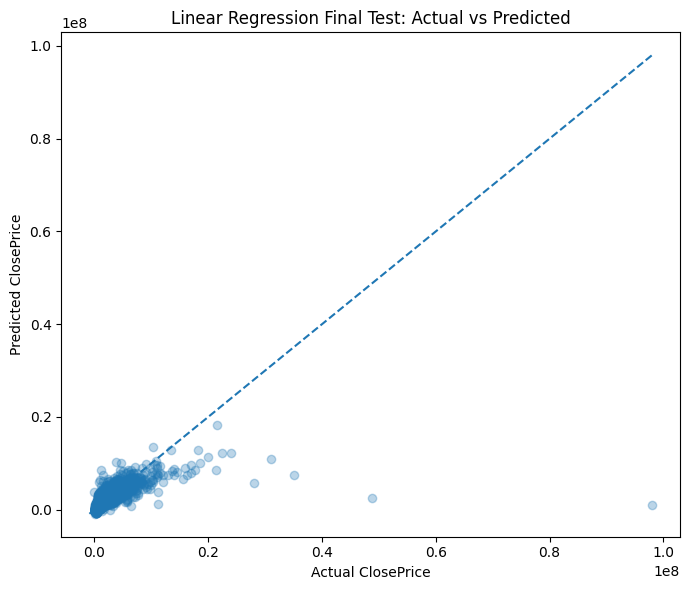

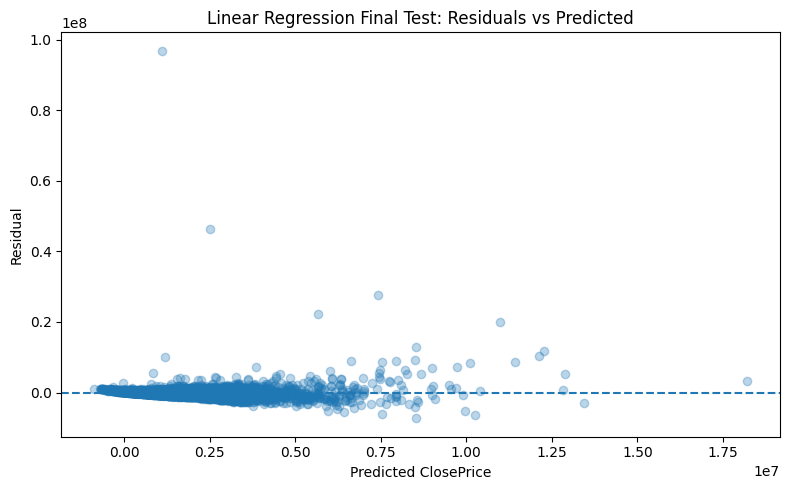

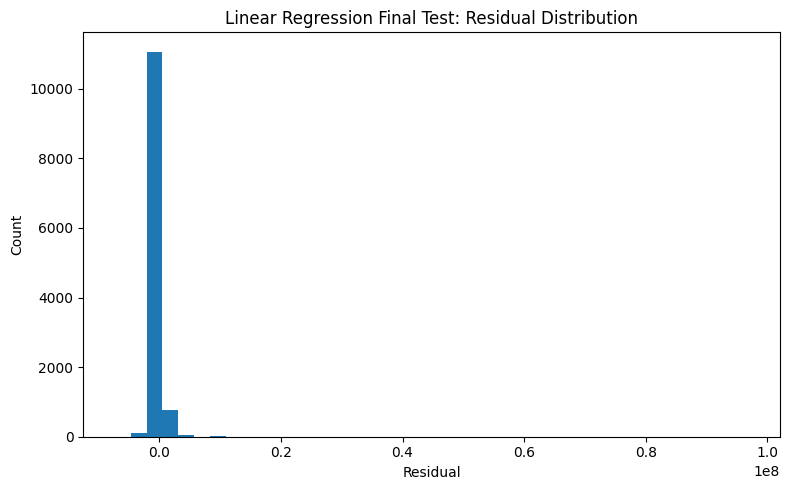

In [24]:
# Plot the final model's test residuals

final_test_residuals = residual_diagnostics(
    y_test,
    test_pred,
    f"{selected_model_name} Final Test"
)

In [25]:
# Create a table of test predictions and errors

test_error_analysis = test_df[["CloseDate", target]].copy()
test_error_analysis["PredictedClosePrice"] = test_pred
test_error_analysis["Residual"] = final_test_residuals
test_error_analysis["AbsoluteError"] = np.abs(final_test_residuals)

worst_predictions = (
    test_error_analysis
    .sort_values("AbsoluteError", ascending=False)
    .head(20)
)

worst_predictions

,CloseDate,ClosePrice,PredictedClosePrice,Residual,AbsoluteError
10192,2026-05-22,97972500.0,1.112804e+06,9.685970e+07,9.685970e+07
8125,2026-05-15,48720000.0,2.508689e+06,4.621131e+07,4.621131e+07
46,2026-05-22,35000000.0,7.429992e+06,2.757001e+07,2.757001e+07
391,2026-05-06,28000000.0,5.660303e+06,2.233970e+07,2.233970e+07
1727,2026-05-28,31000000.0,1.098173e+07,2.001827e+07,2.001827e+07
1462,2026-05-18,21450000.0,8.521867e+06,1.292813e+07,1.292813e+07
894,2026-05-27,24000000.0,1.227764e+07,1.172236e+07,1.172236e+07
10578,2026-05-06,22500000.0,1.213606e+07,1.036394e+07,1.036394e+07
1330,2026-05-27,11150000.0,1.190681e+06,9.959319e+06,9.959319e+06
11085,2026-05-08,17750000.0,8.493712e+06,9.256288e+06,9.256288e+06


In [26]:
# Calculate feature importance for the selected model

if selected_model_name == "Linear Regression":
    importance = np.abs(final_model.named_steps["model"].coef_)
else:
    importance = final_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        "Feature": feature_cols,
        "Importance": importance
    })
    .sort_values("Importance", ascending=False)
)

feature_importance_df.head(20)

,Feature,Importance
2,LivingArea,663416.606445
27,PostalCode_encoded,300890.039315
6,Stories,203271.748469
4,BathroomsTotalInteger,191329.806517
29,MLSAreaMajor_encoded,172537.290352
26,City_encoded,169943.550783
3,BedroomsTotal,130881.140058
5,YearBuilt,111689.015865
15,LivingArea_missing,109369.117774
30,HighSchoolDistrict_encoded,100200.899002


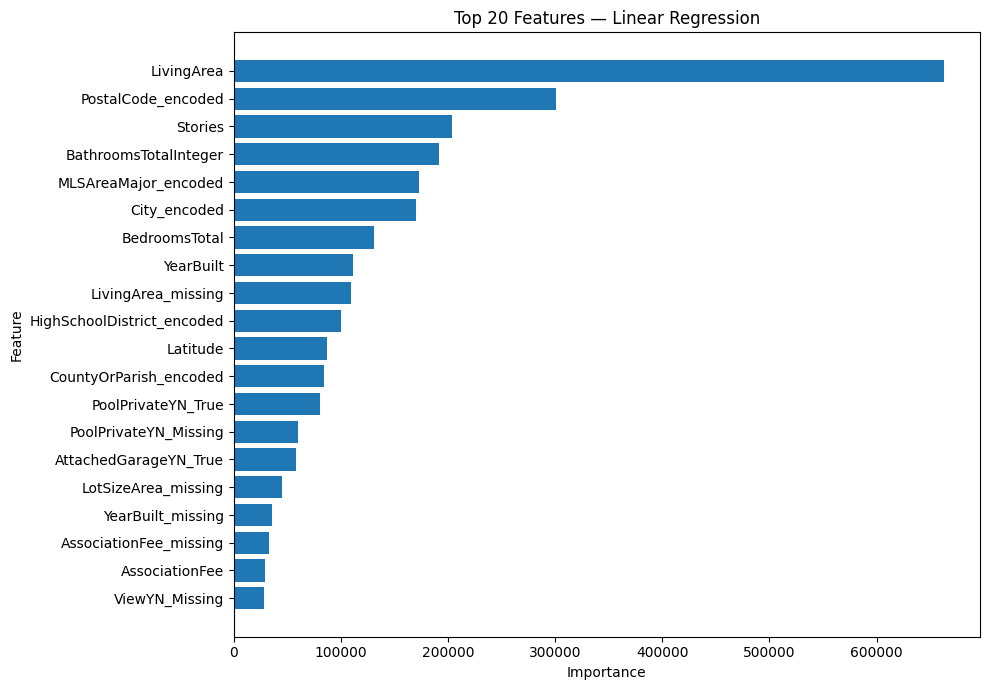

In [27]:
# Plot the top 20 most important features

top_features = feature_importance_df.head(20).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title(f"Top 20 Features — {selected_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [28]:
# Final model comparison table

final_comparison = all_validation_results.copy()

final_comparison["Test R2"] = np.nan
final_comparison["Test RMSE"] = np.nan
final_comparison["Test MAE"] = np.nan
final_comparison["Selected"] = False

selected_mask = (
    (final_comparison["Model"] == selected_model_name) &
    (final_comparison["Data Version"] == selected_data_version)
)

final_comparison.loc[selected_mask, "Test R2"] = final_test_result["R2"]
final_comparison.loc[selected_mask, "Test RMSE"] = final_test_result["RMSE"]
final_comparison.loc[selected_mask, "Test MAE"] = final_test_result["MAE"]
final_comparison.loc[selected_mask, "Selected"] = True

final_comparison

,Model,Data Version,Parameters,R2,RMSE,MAE,Test R2,Test RMSE,Test MAE,Selected
0,Linear Regression,Before Outlier Removal,StandardScaler + LinearRegression,0.015279,9.655655e+06,512612.509236,0.436823,1.259302e+06,417364.936795,True
1,Decision Tree,Before Outlier Removal,"max_depth=5, min_samples_leaf=1",0.013748,9.663158e+06,544814.553638,NaN,NaN,NaN,False
2,Linear Regression,After Outlier Removal,StandardScaler + LinearRegression,0.009456,9.684161e+06,510458.801619,NaN,NaN,NaN,False
3,Random Forest,After Outlier Removal,"n_estimators=100, max_depth=10, min_samples_le...",0.005056,9.705649e+06,471223.490296,NaN,NaN,NaN,False
4,Decision Tree,After Outlier Removal,"max_depth=5, min_samples_leaf=1",0.004563,9.708051e+06,524920.562872,NaN,NaN,NaN,False
5,Random Forest,Before Outlier Removal,"n_estimators=100, max_depth=10, min_samples_le...",0.002356,9.718808e+06,442672.147176,NaN,NaN,NaN,False
